In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report
)

In [2]:
spy  = pd.read_csv('data/SPY_features.csv',  parse_dates=['date'], index_col='date').sort_index()

In [3]:
spy.head()

,adj_close,close,high,low,open,volume,daily_return,weekly_return,ma_7,ma_21,...,lag_return_5,month,quarter,season_num,season,is_earnings_week,vix,is_major_event,target_direction,target_return
date,,,,,,,,,,,,,,,,,,,,,
2015-01-02,170.125015,205.429993,206.880005,204.179993,206.380005,121465900,-0.000535,-0.011262,171.691376,169.676133,...,0.000096,1,1,0,Winter,0,17.790001,0,0,-0.005744
2015-01-05,167.052658,201.720001,204.369995,201.350006,204.169998,169632600,-0.018059,-0.032239,170.977999,169.477819,...,0.003225,1,1,0,Winter,0,19.920000,0,0,0.004610
2015-01-06,165.479141,199.820007,202.720001,198.860001,202.089996,209151400,-0.009419,-0.042641,170.037469,169.213594,...,0.001344,1,1,0,Winter,0,21.120001,0,1,0.011310
2015-01-07,167.541260,202.309998,202.720001,200.880005,201.419998,125346700,0.012462,-0.025481,169.312267,169.034233,...,-0.005366,1,1,0,Winter,0,19.309999,0,1,-0.007167
2015-01-08,170.514206,205.899994,206.160004,203.990005,204.009995,147217800,0.017745,0.001751,168.978638,169.050955,...,-0.009923,1,1,0,Winter,0,17.010000,0,0,-0.033414


In [4]:
FEATURES = [
    'daily_return', 'weekly_return', 'ma_cross', 'dist_from_ma21', 'daily_range',
    'rsi_14', 'macd_hist', 'bb_position', 'volatility_7', 'volatility_20',
    'volume_change', 'volume_ratio',
    'lag_return_1', 'lag_return_3', 'lag_return_5',
    'month', 'is_earnings_week',
    'vix', 'is_major_event'
]
TARGET_CLS = 'target_direction'

In [5]:
spy_cls  = spy[FEATURES + [TARGET_CLS]].dropna().copy()

print(spy_cls.shape)

(2515, 20)


In [6]:
def walk_forward_splits(df, train_window, test_window=42, embargo=5):
    splits = []
    n = len(df)
    start = 0

    while start + train_window + embargo + test_window <= n:
        train_start = start
        train_end   = start + train_window
        test_start  = train_end + embargo
        test_end    = test_start + test_window

        train_idx = list(range(train_start, train_end))
        test_idx  = list(range(test_start, test_end))

        splits.append((train_idx, test_idx))
        start += test_window

    return splits

In [7]:
spy_folds = walk_forward_splits(spy_cls, train_window = 189)
print("SPY folds:", len(spy_folds))

SPY folds: 55


In [8]:
fold_scores = [] # metrics of each fold stored
spy_actual, spy_pred = [], [] # actual and predicted values
spy_probs = [] # P(UP) for each test day across all folds

for train_idx, test_idx in spy_folds:
    X_train = spy_cls.iloc[train_idx][FEATURES]
    y_train = spy_cls.iloc[train_idx][TARGET_CLS]
    X_test  = spy_cls.iloc[test_idx][FEATURES]
    y_test  = spy_cls.iloc[test_idx][TARGET_CLS]

    # standardization
    scaler = StandardScaler()
    X_train = scaler.fit_transform(X_train) 
    X_test  = scaler.transform(X_test) 

   # train + predict
    svm = SVC(kernel='rbf', C=10, gamma=0.1,
              class_weight='balanced', probability=True, random_state=42)
    svm.fit(X_train, y_train)
    y_pred = svm.predict(X_test)
    y_prob = svm.predict_proba(X_test)[:, 1]   # P(class = UP)

    cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
    tn, fp, fn, tp = cm.ravel()
    specificity = tn / (tn + fp) if (tn + fp) > 0 else 0.0

    

    # store fold metrics
    fold_scores.append({
        "accuracy":  accuracy_score(y_test, y_pred),
        "precision": precision_score(y_test, y_pred, zero_division=0),
        "recall":    recall_score(y_test, y_pred, zero_division=0),
        "specificity": specificity,
        "f1":        f1_score(y_test, y_pred, zero_division=0)
    })
    spy_actual.extend(y_test)
    spy_pred.extend(y_pred)
    spy_probs.extend(y_prob)

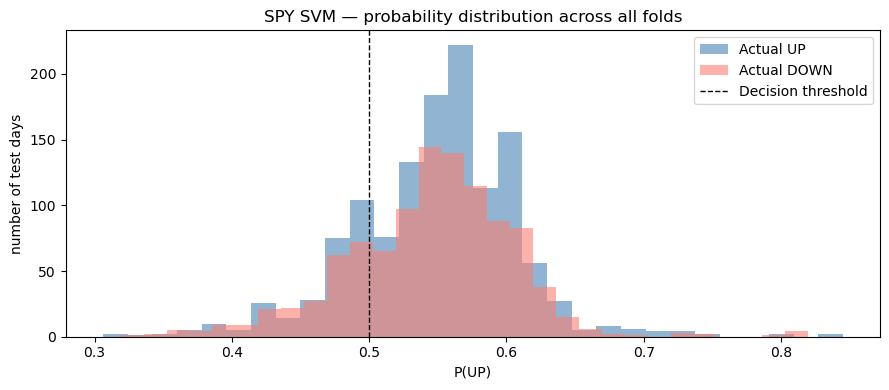

Prob range: 0.306 to 0.845
Mean P(UP) for actual UP days:   0.549
Mean P(UP) for actual DOWN days: 0.545


In [9]:
spy_actual_arr = np.array(spy_actual)
spy_probs_arr  = np.array(spy_probs)

# Distribution plot
fig, ax = plt.subplots(1, 1, figsize=(9, 4))
ax.hist(spy_probs_arr[spy_actual_arr == 1], bins=30, alpha=0.6, label='Actual UP',   color='steelblue')
ax.hist(spy_probs_arr[spy_actual_arr == 0], bins=30, alpha=0.6, label='Actual DOWN', color='salmon')
ax.axvline(0.5, color='black', linestyle='--', linewidth=1, label='Decision threshold')
ax.set_xlabel('P(UP)')
ax.set_ylabel('number of test days')
ax.set_title('SPY SVM — probability distribution across all folds')
ax.legend()
plt.tight_layout()
plt.show()

print(f"Prob range: {spy_probs_arr.min():.3f} to {spy_probs_arr.max():.3f}")
print(f"Mean P(UP) for actual UP days:   {spy_probs_arr[spy_actual_arr == 1].mean():.3f}")
print(f"Mean P(UP) for actual DOWN days: {spy_probs_arr[spy_actual_arr == 0].mean():.3f}")

In [10]:
spy_results = pd.DataFrame(fold_scores)
spy_results

,accuracy,precision,recall,specificity,f1
0,0.595238,0.500000,0.294118,0.800000,0.370370
1,0.523810,0.515152,0.809524,0.238095,0.629630
2,0.619048,0.695652,0.640000,0.588235,0.666667
3,0.619048,0.700000,0.583333,0.666667,0.636364
4,0.428571,0.470588,0.347826,0.526316,0.400000
5,0.500000,0.500000,0.333333,0.666667,0.400000
6,0.380952,0.466667,0.583333,0.111111,0.518519
7,0.476190,0.500000,0.636364,0.300000,0.560000
8,0.547619,0.588235,0.454545,0.650000,0.512821
9,0.428571,0.444444,0.571429,0.285714,0.500000


In [11]:
spy_results.describe()

,accuracy,precision,recall,specificity,f1
count,55.000000,55.000000,55.000000,55.000000,55.000000
mean,0.507359,0.563239,0.553401,0.457068,0.529820
std,0.075414,0.114696,0.211818,0.225057,0.133370
min,0.333333,0.296296,0.111111,0.000000,0.176471
25%,0.452381,0.492424,0.437391,0.279221,0.479130
50%,0.523810,0.555556,0.578947,0.444444,0.545455
75%,0.547619,0.625000,0.652174,0.620137,0.612245
max,0.738095,1.000000,1.000000,1.000000,0.800000


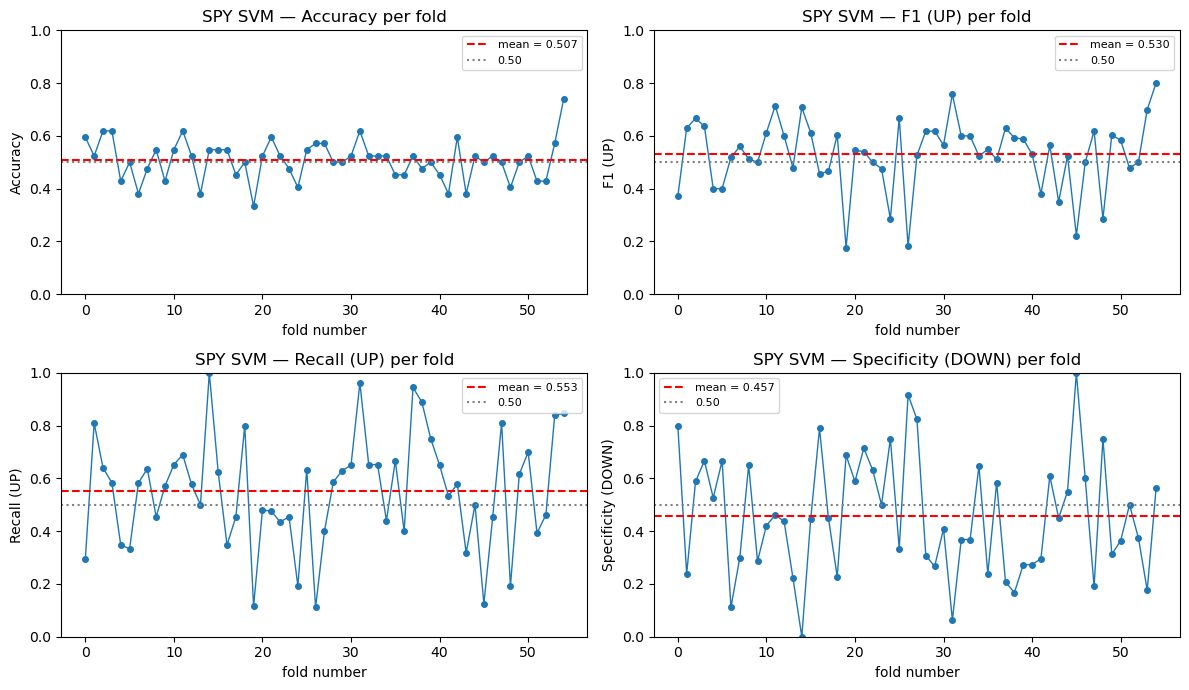

In [12]:
fig, axes = plt.subplots(2, 2, figsize=(12, 7))

metrics = [
    ('accuracy',    'Accuracy',    axes[0, 0]),
    ('f1',          'F1 (UP)',     axes[0, 1]),
    ('recall',      'Recall (UP)', axes[1, 0]),
    ('specificity', 'Specificity (DOWN)', axes[1, 1]),
]

for col, label, ax in metrics:
    ax.plot(spy_results.index, spy_results[col], marker='o', linewidth=1, markersize=4)
    ax.axhline(spy_results[col].mean(), color='red', linestyle='--',
               label=f'mean = {spy_results[col].mean():.3f}')
    ax.axhline(0.5, color='gray', linestyle=':', label='0.50')
    ax.set_xlabel('fold number')
    ax.set_ylabel(label)
    ax.set_title(f'SPY SVM — {label} per fold')
    ax.set_ylim(0, 1)
    ax.legend(fontsize=8)

plt.tight_layout()
plt.show()

In [13]:
print(classification_report(spy_actual, spy_pred, zero_division=0))

              precision    recall  f1-score   support

           0       0.45      0.45      0.45      1038
           1       0.55      0.55      0.55      1272

    accuracy                           0.51      2310
   macro avg       0.50      0.50      0.50      2310
weighted avg       0.51      0.51      0.51      2310



In [14]:
C_values     = [0.1, 1, 10, 100, 1000]
gamma_values = [0.001, 0.01, 0.1, 1, 10]

print(f'Grid: {len(C_values)} × {len(gamma_values)} = {len(C_values) * len(gamma_values)} combinations')
print(f'Folds per combo: {len(spy_folds)}')
print(f'Total SVM fits: {len(C_values) * len(gamma_values) * len(spy_folds)}')

Grid: 5 × 5 = 25 combinations
Folds per combo: 55
Total SVM fits: 1375


In [15]:
grid_results = []

for C in C_values:
    for gamma in gamma_values:
        fold_f1s   = []
        fold_accs  = []
        fold_precs = []
        fold_recs  = []
        fold_specs = []   

        for train_idx, test_idx in spy_folds:
            X_train = spy_cls.iloc[train_idx][FEATURES]
            y_train = spy_cls.iloc[train_idx][TARGET_CLS]
            X_test  = spy_cls.iloc[test_idx][FEATURES]
            y_test  = spy_cls.iloc[test_idx][TARGET_CLS]

            scaler  = StandardScaler()
            X_train = scaler.fit_transform(X_train)
            X_test  = scaler.transform(X_test)

            svm = SVC(kernel='rbf', C=C, gamma=gamma,
                      class_weight='balanced', random_state=42)
            svm.fit(X_train, y_train)
            y_pred = svm.predict(X_test)

            fold_f1s.append(f1_score(y_test, y_pred, zero_division=0))
            fold_accs.append(accuracy_score(y_test, y_pred))
            fold_precs.append(precision_score(y_test, y_pred, zero_division=0))
            fold_recs.append(recall_score(y_test, y_pred, zero_division=0))

            # Specificity = TN / (TN + FP) = recall of the DOWN class
            cm = confusion_matrix(y_test, y_pred, labels=[0, 1])
            tn, fp, fn, tp = cm.ravel()
            spec = tn / (tn + fp) if (tn + fp) > 0 else 0.0
            fold_specs.append(spec)

        grid_results.append({
            'C': C,
            'gamma': gamma,
            'f1':          np.mean(fold_f1s),
            'accuracy':    np.mean(fold_accs),
            'precision':   np.mean(fold_precs),
            'recall':      np.mean(fold_recs),
            'specificity': np.mean(fold_specs),
        })
        print(f'  C={C:>6}  gamma={gamma:<6}  '
              f'F1={np.mean(fold_f1s):.3f}  '
              f'acc={np.mean(fold_accs):.3f}  '
              f'prec={np.mean(fold_precs):.3f}  '
              f'rec={np.mean(fold_recs):.3f}  '
              f'spec={np.mean(fold_specs):.3f}')

grid_df = pd.DataFrame(grid_results)

  C=   0.1  gamma=0.001   F1=0.374  acc=0.508  prec=0.293  rec=0.527  spec=0.473
  C=   0.1  gamma=0.01    F1=0.375  acc=0.510  prec=0.294  rec=0.525  spec=0.479
  C=   0.1  gamma=0.1     F1=0.374  acc=0.508  prec=0.293  rec=0.527  spec=0.473
  C=   0.1  gamma=1       F1=0.374  acc=0.508  prec=0.293  rec=0.527  spec=0.473
  C=   0.1  gamma=10      F1=0.374  acc=0.508  prec=0.293  rec=0.527  spec=0.473
  C=     1  gamma=0.001   F1=0.341  acc=0.502  prec=0.392  rec=0.412  spec=0.593
  C=     1  gamma=0.01    F1=0.457  acc=0.495  prec=0.545  rec=0.487  spec=0.516
  C=     1  gamma=0.1     F1=0.523  acc=0.501  prec=0.537  rec=0.558  spec=0.430
  C=     1  gamma=1       F1=0.608  acc=0.549  prec=0.509  rec=0.816  spec=0.189
  C=     1  gamma=10      F1=0.599  acc=0.552  prec=0.470  rec=0.836  spec=0.164
  C=    10  gamma=0.001   F1=0.431  acc=0.485  prec=0.544  rec=0.447  spec=0.545
  C=    10  gamma=0.01    F1=0.490  acc=0.495  prec=0.538  rec=0.520  spec=0.464
  C=    10  gamma=0.1     F1

In [16]:
print('Top 5 by F1:')
print(grid_df.sort_values('f1', ascending=False).head().to_string(index=False))

print('Top 5 by ACCURACY:')
print(grid_df.sort_values('accuracy', ascending=False).head().to_string(index=False))

print('Top 5 by Precision:')
print(grid_df.sort_values('precision', ascending=False).head().to_string(index=False))

print('Top 5 by Recall:')
print(grid_df.sort_values('recall', ascending=False).head().to_string(index=False))

print('Top 5 by Specificity :')
print(grid_df.sort_values('specificity', ascending=False).head().to_string(index=False))

print('\nCurrent baseline (C=10, gamma=0.1):')
print(grid_df[(grid_df['C'] == 10) & (grid_df['gamma'] == 0.1)].to_string(index=False))

Top 5 by F1:
     C  gamma       f1  accuracy  precision   recall  specificity
   1.0    1.0 0.608283  0.548918   0.509211 0.815883     0.189229
1000.0   10.0 0.599234  0.552381   0.469697 0.836364     0.163636
 100.0   10.0 0.599234  0.552381   0.469697 0.836364     0.163636
  10.0   10.0 0.599234  0.552381   0.469697 0.836364     0.163636
   1.0   10.0 0.599234  0.552381   0.469697 0.836364     0.163636
Top 5 by ACCURACY:
     C  gamma       f1  accuracy  precision   recall  specificity
1000.0   10.0 0.599234  0.552381   0.469697 0.836364     0.163636
 100.0   10.0 0.599234  0.552381   0.469697 0.836364     0.163636
  10.0   10.0 0.599234  0.552381   0.469697 0.836364     0.163636
   1.0   10.0 0.599234  0.552381   0.469697 0.836364     0.163636
1000.0    1.0 0.591478  0.549351   0.508666 0.797579     0.208367
Top 5 by Precision:
     C  gamma       f1  accuracy  precision   recall  specificity
 100.0  0.100 0.537672  0.512987   0.565995 0.563915     0.455204
1000.0  0.100 0.537856  